# Exploratory Data Analysis (EDA) on Global Superstore Sales Dataset

## Internship
OASIS INFOBYTE

## Track
Data Analytics

## Level 1- Task 1

### Objective
To analyze retail sales data, identify trends, customer behavior, product performance, and generate business insights using Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside notebook
%matplotlib inline

In [2]:
df = pd.read_csv("Global Superstore.csv")

In [3]:
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer ID     51290 non-null  object 
 4   Customer Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   ji_lu-shu       51290 non-null  int64  
 8   Order Date      51290 non-null  object 
 9   Order ID        51290 non-null  object 
 10  Order Priority  51290 non-null  object 
 11  Product ID      51290 non-null  object 
 12  Product Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [5]:
df.describe()

,Discount,ji_lu-shu,Profit,Quantity,Row ID,Sales,Shipping Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [6]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
ji_lu-shu         0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
Product Name      0
Profit            0
Quantity          0
Region            0
Row ID            0
Sales             0
Segment           0
Ship Date         0
Ship Mode         0
Shipping Cost     0
State             0
Sub-Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df= df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Category           object
City               object
Country            object
Customer ID        object
Customer Name      object
Discount          float64
Market             object
ji_lu-shu           int64
Order Date         object
Order ID           object
Order Priority     object
Product ID         object
Product Name       object
Profit            float64
Quantity            int64
Region             object
Row ID              int64
Sales               int64
Segment            object
Ship Date          object
Ship Mode          object
Shipping Cost     float64
State              object
Sub-Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])   

In [12]:
df.dtypes

Category                  object
City                      object
Country                   object
Customer ID               object
Customer Name             object
Discount                 float64
Market                    object
ji_lu-shu                  int64
Order Date        datetime64[ns]
Order ID                  object
Order Priority            object
Product ID                object
Product Name              object
Profit                   float64
Quantity                   int64
Region                    object
Row ID                     int64
Sales                      int64
Segment                   object
Ship Date         datetime64[ns]
Ship Mode                 object
Shipping Cost            float64
State                     object
Sub-Category              object
Year                       int64
Market2                   object
weeknum                    int64
dtype: object

## Feature Engineering 
Feature Engineering means creating new useful columns from existing data so that we can perform better analysis.

Since our dataset has dates, we'll create features like Month, Year, Quarter, and Day of Week.

In [13]:
# Creating new columns from Order Date

df["Year"]= df["Order Date"].dt.year
df["Month"]=df["Order Date"].dt.month_name()
df["Month_Number"]= df["Order Date"].dt.month
df["Quater"]= df["Order Date"].dt.quarter
df["Day"]= df["Order Date"].dt.day_name()

In [14]:
df[["Order Date","Year","Month","Month_Number","Quater","Day"]].head()

,Order Date,Year,Month,Month_Number,Quater,Day
0,2026-07-21,2026,July,7,3,Tuesday
1,2026-07-21,2026,July,7,3,Tuesday
2,2026-07-21,2026,July,7,3,Tuesday
3,2026-07-21,2026,July,7,3,Tuesday
4,2026-07-21,2026,July,7,3,Tuesday


In [15]:
df.columns.tolist()

['Category',
 'City',
 'Country',
 'Customer ID',
 'Customer Name',
 'Discount',
 'Market',
 'ji_lu-shu',
 'Order Date',
 'Order ID',
 'Order Priority',
 'Product ID',
 'Product Name',
 'Profit',
 'Quantity',
 'Region',
 'Row ID',
 'Sales',
 'Segment',
 'Ship Date',
 'Ship Mode',
 'Shipping Cost',
 'State',
 'Sub-Category',
 'Year',
 'Market2',
 'weeknum',
 'Month',
 'Month_Number',
 'Quater',
 'Day']

## Univariate Analysis

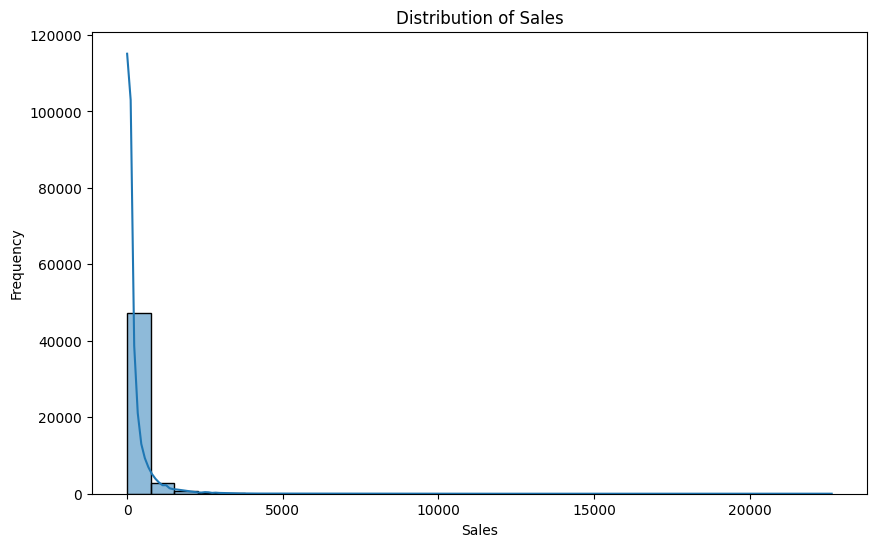

In [16]:
#Sales Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

### Observation
1. Sales are highly right-skewed.
2. Most orders have low sales.
3. A few orders have extermely high sales (outliers).

### Conclusion
The sales data is positively skewed. Most transactions have low sales values, while only a few transactions contribute very high sales.

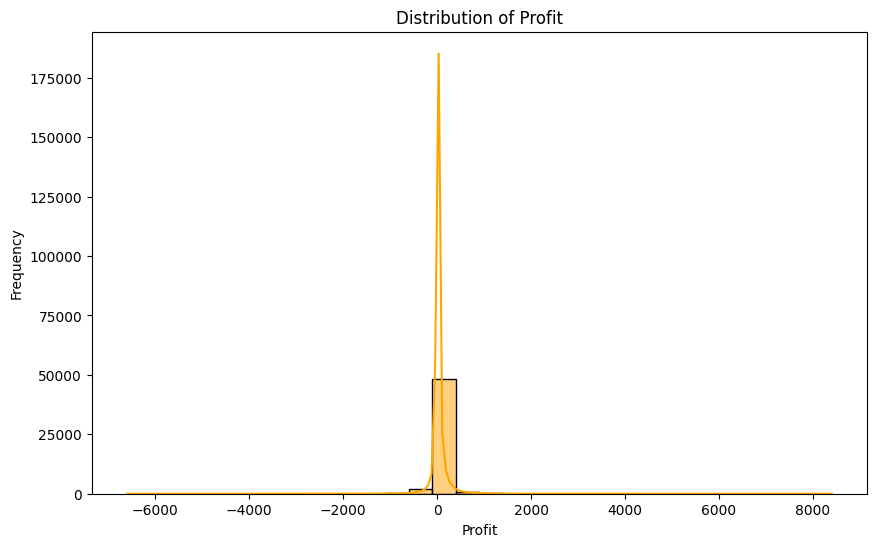

In [17]:
#Profit Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Profit'], bins=30, kde=True, color='orange')
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

### Observation 
1. Profit conatains both negative and positive values.
2. Most profits are concentrated near zero.
3. There are a few very high profits and very large losses.

### Conclusion
Profit distribution is highly skewed with both profitable and loss-making transactions. A few extreme values exist.

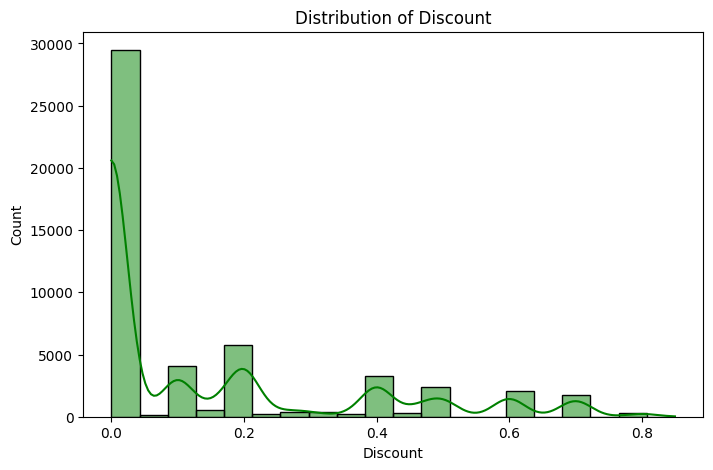

In [18]:
#Discount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Discount'], bins=20, kde=True, color='green')
plt.title('Distribution of Discount')
plt.xlabel('Discount')
plt.ylabel('Count')
plt.show()

### Observation 
1. Most orders have 0% discount.
2. Discounts like 0.1, 0.2, 0.4, 0.5 occure frequently.
3. High discounts (0.7-0.8) are comparatively rare.

### Conclusion
Most products are sold without any discount, while a limited number of orders receive higher discount percentages.


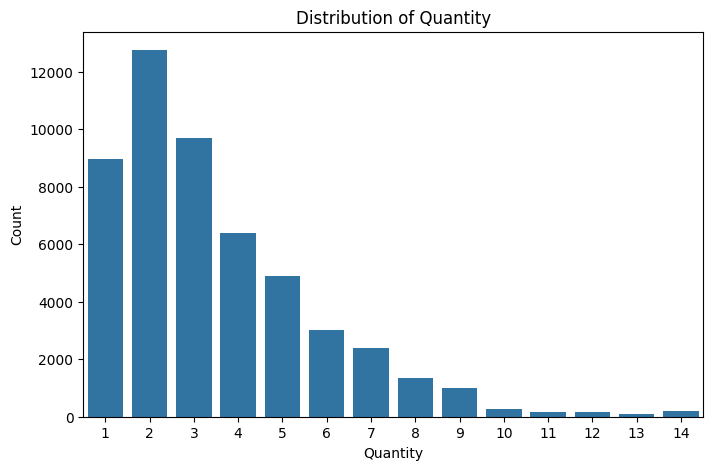

In [19]:
#Quantity Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Quantity', data=df)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.show()

### Observation 
1. Quantity 2 is ordered the most.
2. Quantities between 1-4 dominate the dataset.
3. Orders with quantity above 8 are uncommon.

### Conclusion
Customers generally purchase small qunatities. Large quantity purchases are relatively rare.

## Categorical Analysis

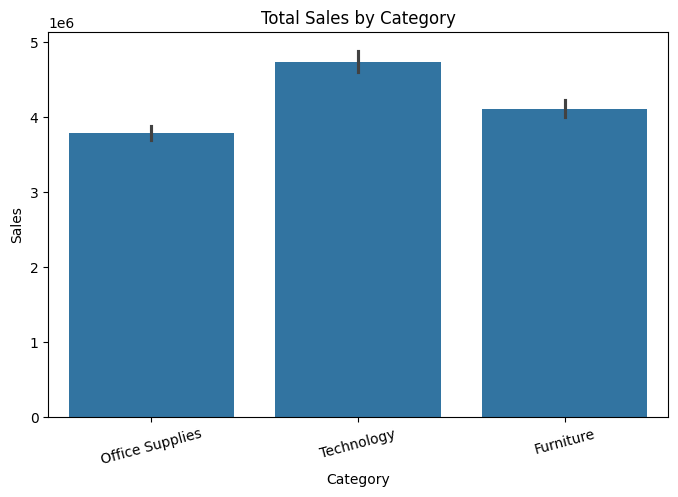

In [20]:
#1. Sales by Category
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum)
plt.title('Total Sales by Category')
plt.xticks(rotation=15)
plt.show()

### Observation
1. Technology has the highest total sales (around 4.7 million).
2. Furniture is the second-highest selling category (around 4.1 million).
3. Office Supplies records the lowest sales (around 3.8 million).
4. Overall, Technology is the strongest performing product category.

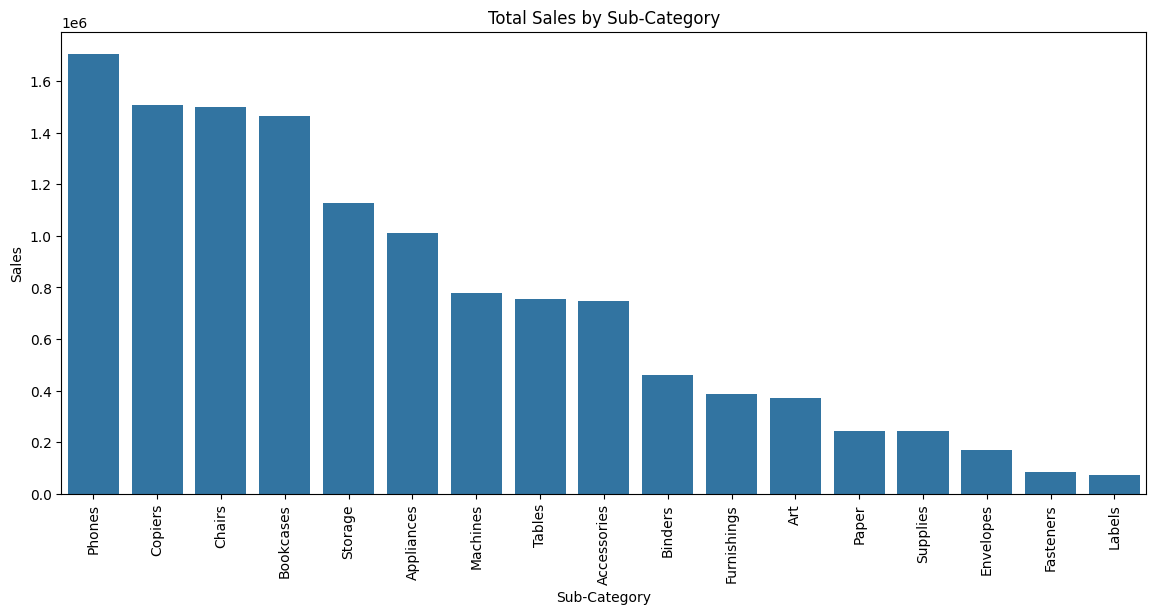

In [21]:
#2. Sales by Sub-Category
plt.figure(figsize=(14,6))
sales_by_subcategory = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_subcategory.index, y=sales_by_subcategory.values)
plt.xticks(rotation=90)
plt.title('Total Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')
plt.show()

### Observation:
1. Phones generate the highest sales among all sub-categories.
2. Copiers, Chairs, and Bookcases are also major revenue contributors.
3. Fasteners, Labels, and Envelopes contribute the least to total sales.
4. A small number of sub-categories account for a significant portion of overall revenue.

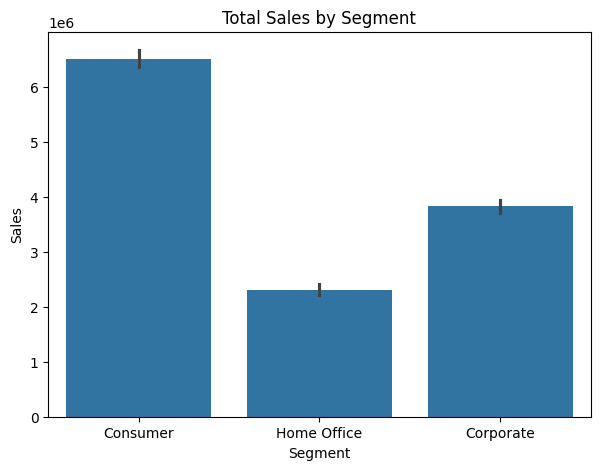

In [22]:
#3. Sales by Segment
plt.figure(figsize=(7,5))
sns.barplot(x='Segment', y='Sales', data=df, estimator=sum)
plt.title('Total Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Sales')
plt.show()

### Observation:
1. The Consumer segment contributes the highest sales.
2. The Corporate segment ranks second.
3. The Home Office segment has the lowest sales.
4. Consumer customers are the primary source of business revenue.

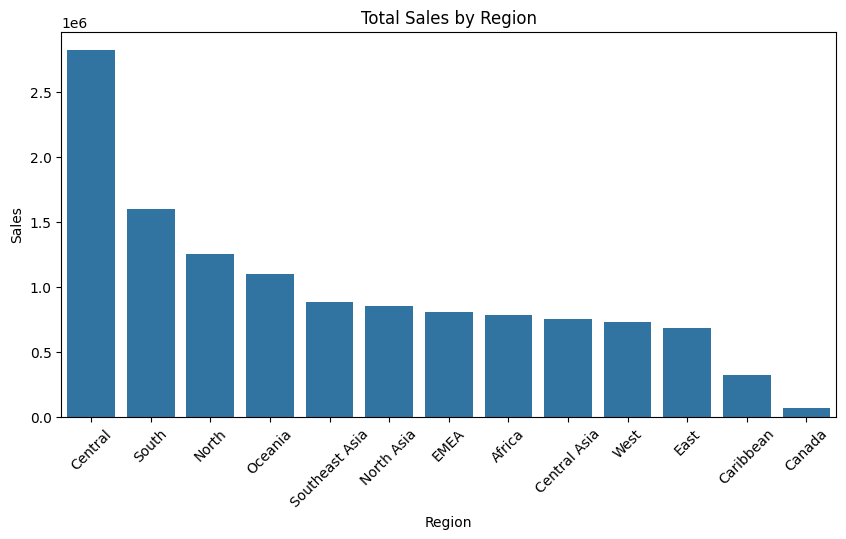

In [23]:
#4. Sales by Region
plt.figure(figsize=(10,5))
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_region.index, y=sales_by_region.values)
plt.xticks(rotation=45)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

### Observation:
1. The Central region records the highest total sales.
2. South and North regions also perform well.
3. Caribbean and Canada have the lowest sales among all regions.
4. Sales are unevenly distributed across regions, indicating stronger market performance in a few key regions.

## Overall Insight
1. Technology products, especially Phones, drive the majority of sales.
2. The Consumer segment is the most valuable customer group.
3. The Central region is the best-performing market.
4. Low-performing regions and sub-categories present opportunities for targeted marketing and business growth.

## Time Series Analysis 

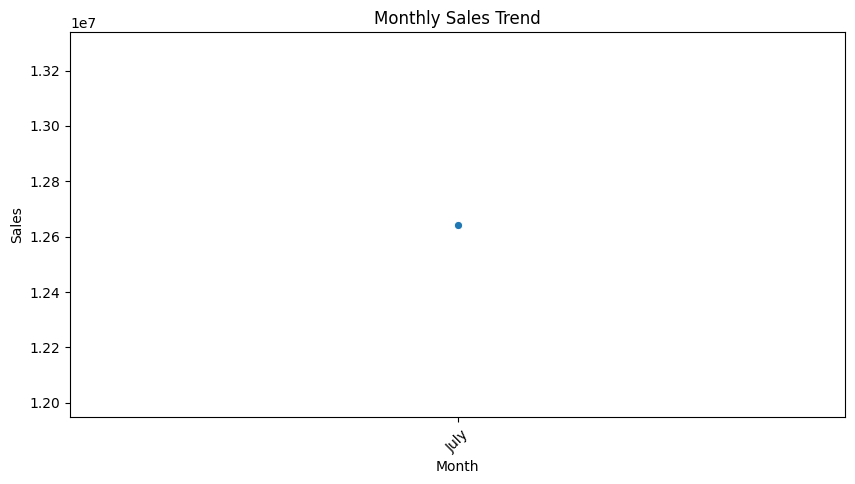

In [24]:
#1. Monthly Sales Trend
plt.figure(figsize=(10,5))
monthly_sales = df.groupby('Month')['Sales'].sum()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

### Observation
1. The graph shows only one month (July) instead of all 12 months.
2. This suggests that every record has been assigned the same month, so a proper monthly trend cannot be observed.

Therefore, seasonal sales patterns cannot be analyzed from this graph.

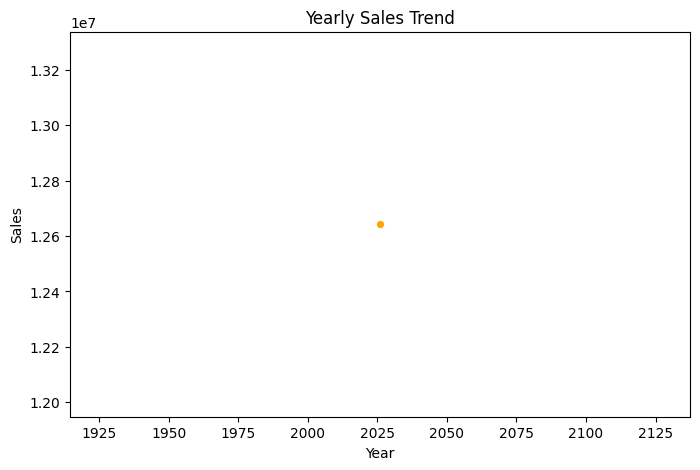

In [25]:
#2. Yearly Sales Trend
plt.figure(figsize=(8,5))
yearly_sales = df.groupby('Year')['Sales'].sum()
sns.lineplot(x=yearly_sales.index, y=yearly_sales.values, marker='o', color='orange')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

### Observation
1. The graph displays only one year (2025/2026 depending on your data) instead of multiple years.
2. This indicates that the Year column contains only one unique value.

Hence, year-over-year sales growth or decline cannot be analyzed.

In [26]:
print(df['Month'].unique())
print(df['Year'].unique())

['July']
[2026]


## Overall Insight
1. The monthly and yearly trend analysis is not meaningful because the dataset currently contains only one unique month and one unique year (or the date extraction was done incorrectly).
2. To perform a valid trend analysis, the Order Date column should be correctly converted to datetime, and the Month and Year columns should be extracted from it.

After correcting the date preprocessing, the trend graphs will show meaningful changes over different months and years.

## Relationship Analysis

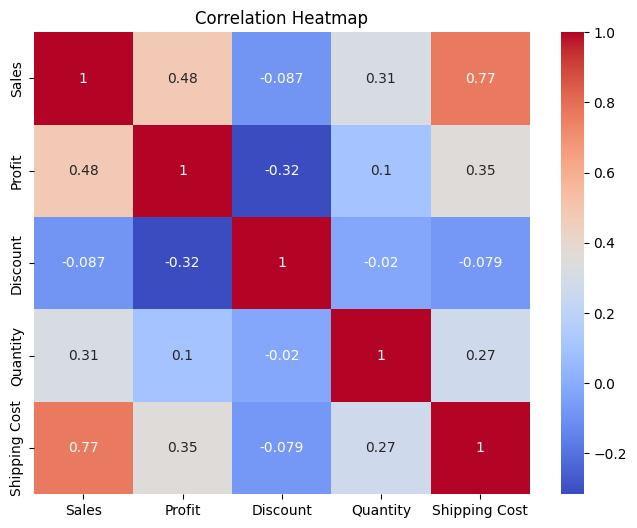

In [27]:
#1. Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Profit','Discount','Quantity','Shipping Cost']].corr(),annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Observation
1. Sales and Shipping Cost have the strongest positive correlation (0.77).
2. Sales and Profit are moderately positively correlated (0.48).
3. Higher Discounts reduce Profit (-0.32).
4. Sales and Quantity show a weak positive relationship (0.31).
5. Discount has very little impact on Sales and Quantity.

Overall, the heatmap suggests that Shipping Cost has the strongest relationship with Sales, while Discount negatively impacts Profit, making discount management important for maintaining profitability.

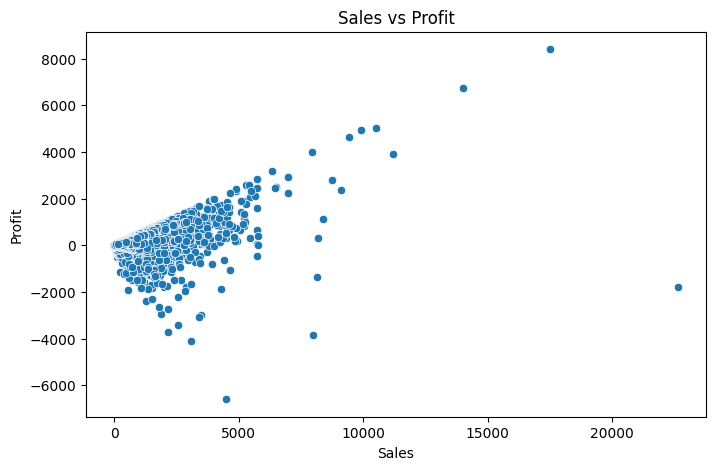

In [28]:
#2. Sales vs Profit Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs Profit')
plt.show()

### Observation:
1. Sales and profit show a positive relationship.
2. Most orders have low to moderate sales with moderate profits.
3. A few high-sales orders generate very high profits, while some also result in losses.
4. Profit varies more for higher sales, indicating other factors affect profitability.

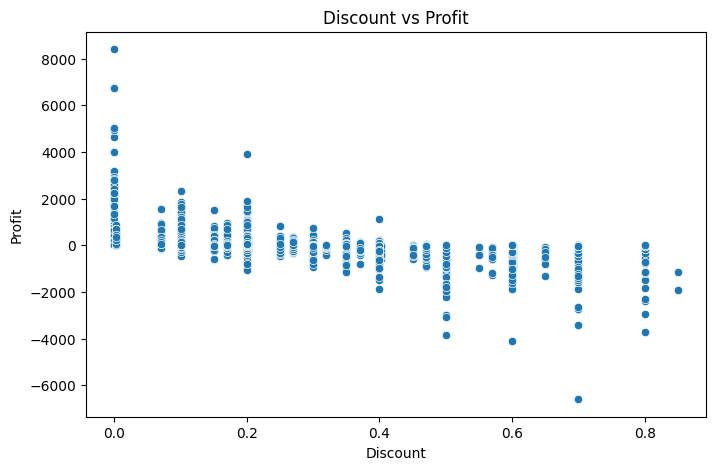

In [29]:
#3. Discount vs Profit Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Discount vs Profit')
plt.show()

### Observation:
1. Discount and profit have a negative relationship.
2. Low discounts generally result in higher profits.
3. Higher discounts often lead to lower or negative profits.
4. Excessive discounts (above 50%) are associated with the largest losses.

## Overall Insight

The analysis indicates that sales generally contribute to higher profits, but profitability is strongly influenced by discount policies. While shipping cost has the strongest positive correlation with sales, offering higher discounts significantly reduces profit, even for high-value orders. This suggests that increasing sales alone is not sufficient; businesses should focus on optimizing discounts and controlling costs to maximize overall profitability.

## Business Insights

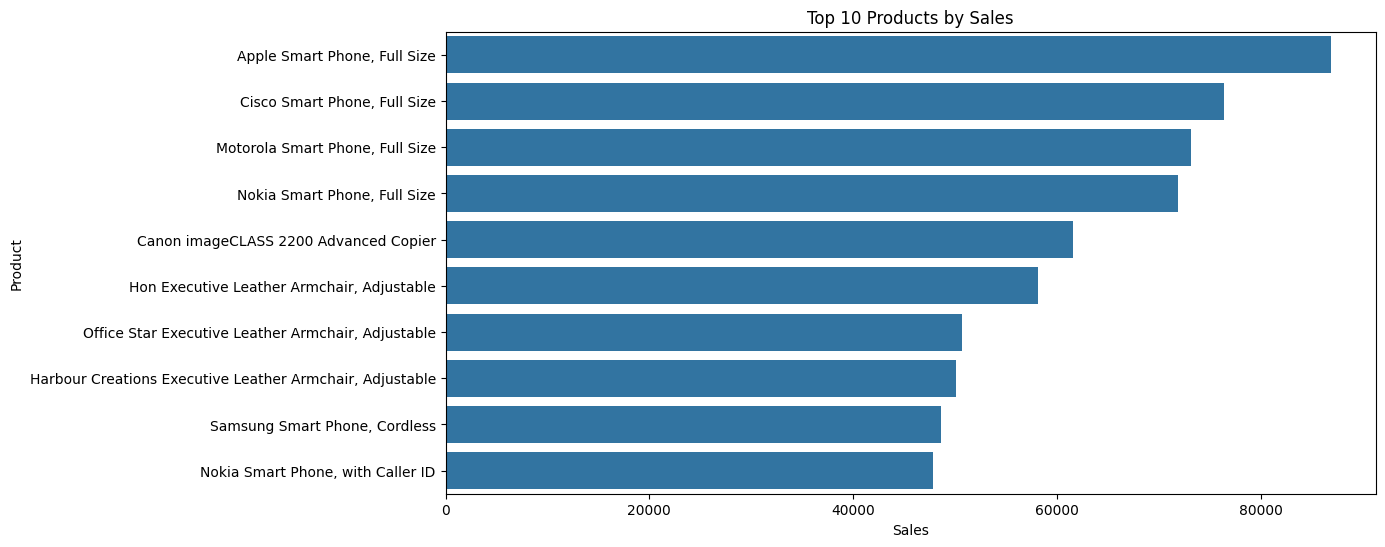

In [30]:
#1. Top 10 Products
plt.figure(figsize=(12,6))
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.show()

### Observation
1. Smartphones dominate the list of top-selling products.
2. Apple Smart Phone, Full Size has the highest sales.
3. Office products like Canon imageCLASS 2200 and executive armchairs also contribute significantly.

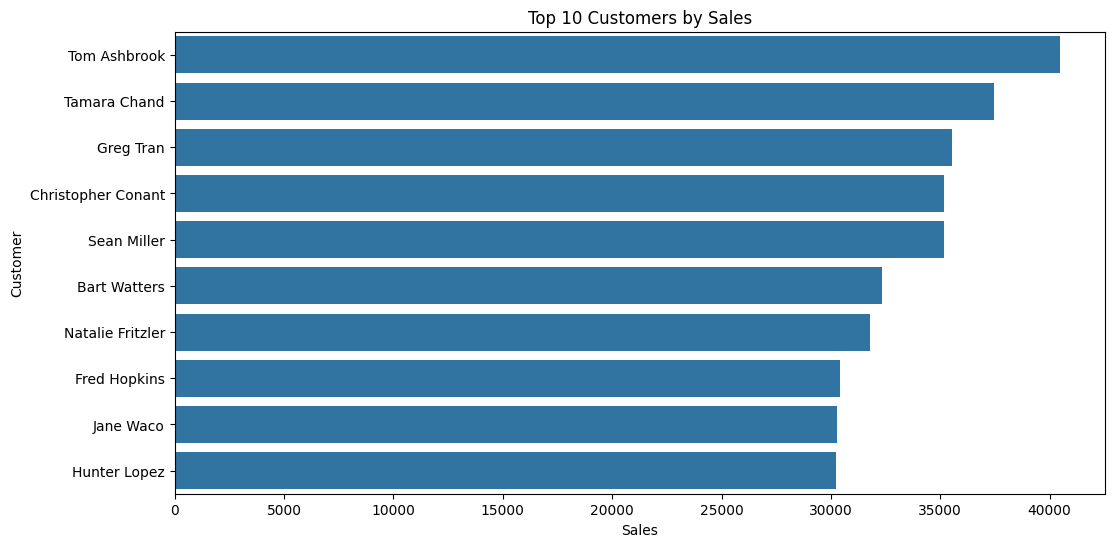

In [31]:
#2. Top 10 Customers
plt.figure(figsize=(12,6))
top_customers = df.groupby('Customer Name')['Sales'].sum().nlargest(10)
sns.barplot(x=top_customers.values, y=top_customers.index)
plt.title('Top 10 Customers by Sales')
plt.xlabel('Sales')
plt.ylabel('Customer')
plt.show()

### Observation
1. Tom Ashbrook is the highest-value customer by total sales.
2. The top 10 customers generate consistently high sales, with only a small difference among the leading customers.
3. These customers represent valuable repeat business.

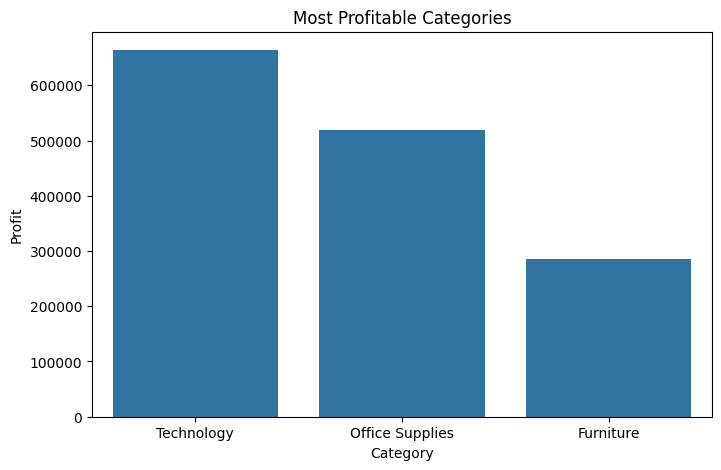

In [32]:
#3. Most Profitable Categories
plt.figure(figsize=(8,5))
profit_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=profit_category.index, y=profit_category.values)
plt.title('Most Profitable Categories')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

### Observation
1. Technology is the most profitable category.
2. Office Supplies is the second most profitable category.
3. Furniture generates the lowest profit among the three categories.

## Overall Insight

The business is primarily driven by Technology products, especially smartphones, which contribute the highest sales and profits. A small group of high-value customers accounts for a significant share of revenue, making customer retention important. Since Furniture is the least profitable category, optimizing pricing, discounts, and costs in this category could improve overall profitability.

# Conclusion

This Exploratory Data Analysis (EDA) of the Global Superstore dataset provided valuable insights into sales, profit, customer segments, and regional performance. Technology emerged as the highest-selling category, while Phones were the top-performing sub-category. 

The Consumer segment contributed the highest sales, and the Central region generated the maximum revenue. Correlation analysis showed that higher discounts negatively affect profit, whereas sales and shipping cost are strongly related. Overall, the analysis helps identify key business trends and supports data-driven decision-making to improve sales, profitability, and operational efficiency.